In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import json
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

plt.rcParams["figure.dpi"]      = 120
plt.rcParams["font.family"]     = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

MODEL_PATH   = "../models/isolation_forest.joblib"
METRICS_PATH = "../models/metrics.json"
DATA_PATH    = "../data/login_events.csv"
NORMAL_PATH  = "../data/normal_samples.csv"
ATTACK_PATH  = "../data/attack_samples.csv"

FEATURE_COLS = [
    "hour_of_day",
    "failed_attempts",
    "device_hash",
    "geo_hash",
    "ip_hash",
    "login_freq",
]

BLENDED_RULE_WEIGHT = 0.6
BLENDED_ML_WEIGHT   = 0.4

print("Imports loaded.")

Imports loaded.


In [2]:
model   = joblib.load(MODEL_PATH)
df_full = pd.read_csv(DATA_PATH)
df_norm = pd.read_csv(NORMAL_PATH)
df_atk  = pd.read_csv(ATTACK_PATH)

with open(METRICS_PATH) as f:
    metrics = json.load(f)

def compute_features(df: pd.DataFrame) -> np.ndarray:
    d = df.copy()
    d["hour_of_day"]     = d["hour_of_day"] / 23.0
    d["failed_attempts"] = d["failed_attempts"] / 10.0
    d["device_hash"]     = (d["device_hash"] % 1000) / 1000.0
    d["geo_hash"]        = (d["geo_hash"]    % 1000) / 1000.0
    d["ip_hash"]         = (d["ip_hash"]     % 1000) / 1000.0
    d["login_freq"]      = (
        d.groupby("user_id")["timestamp_unix"]
        .transform("count") / 100.0
    )
    return d[FEATURE_COLS].values.astype(np.float32)

X_full   = compute_features(df_full)
scores   = model.decision_function(X_full)
labels   = df_full["label"].values
preds    = np.where(model.predict(X_full) == -1, 1, 0)

df_full["ml_score"]    = scores
df_full["ml_pred"]     = preds

print(f"Dataset     : {len(df_full):,} rows")
print(f"Normal      : {(labels == 0).sum():,}")
print(f"Attack      : {(labels == 1).sum():,}")
print(f"Score range : {scores.min():.4f} to {scores.max():.4f}")

Dataset     : 10,500 rows
Normal      : 10,000
Attack      : 500
Score range : -0.1466 to 0.1757


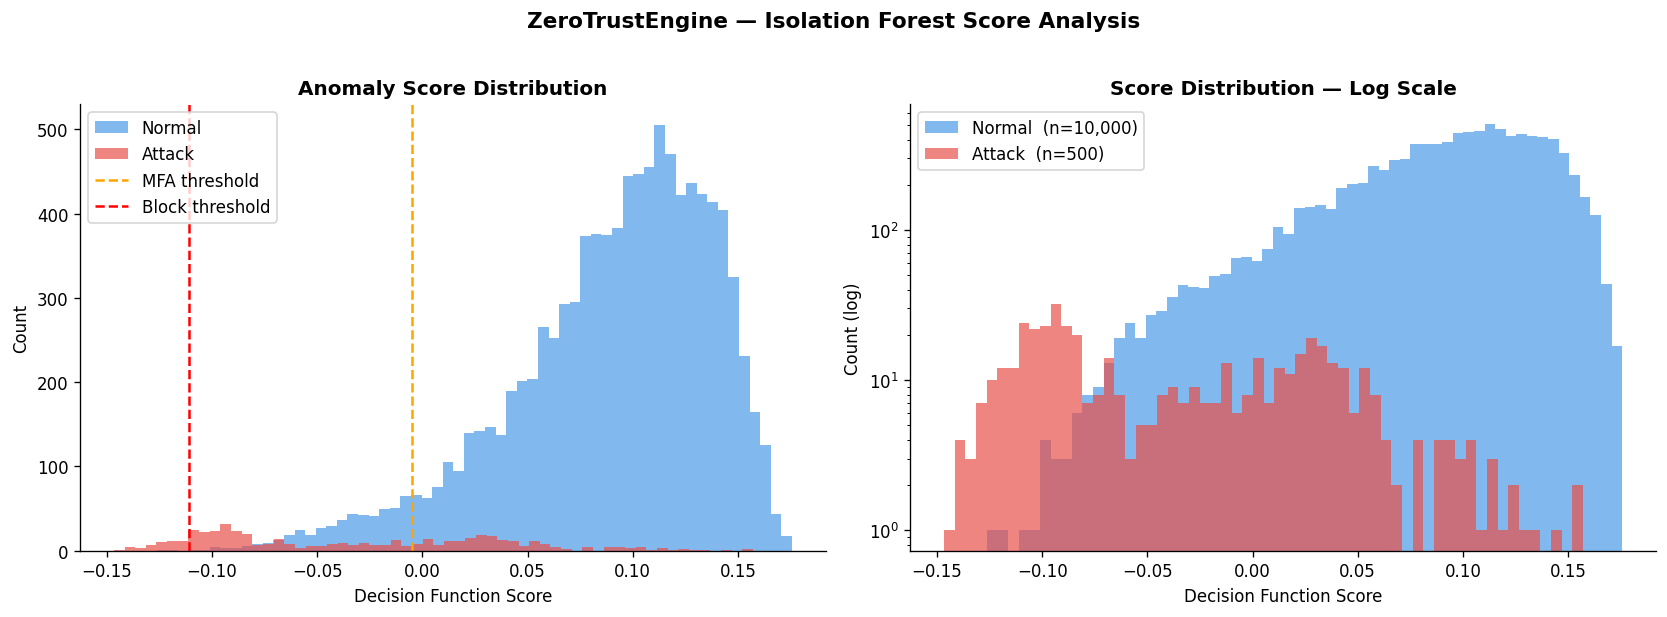

Plot saved → notebooks/score_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_scores = scores[labels == 0]
attack_scores = scores[labels == 1]

axes[0].hist(normal_scores, bins=60, color="#4C9BE8", alpha=0.7, label="Normal")
axes[0].hist(attack_scores, bins=60, color="#E8514C", alpha=0.7, label="Attack")
axes[0].axvline(metrics["thresholds"]["threshold_mfa"],
                color="orange", linestyle="--", linewidth=1.5, label="MFA threshold")
axes[0].axvline(metrics["thresholds"]["threshold_block"],
                color="red", linestyle="--", linewidth=1.5, label="Block threshold")
axes[0].set_title("Anomaly Score Distribution", fontweight="bold")
axes[0].set_xlabel("Decision Function Score")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(normal_scores, bins=60, color="#4C9BE8", alpha=0.7,
             label=f"Normal  (n={len(normal_scores):,})")
axes[1].hist(attack_scores, bins=60, color="#E8514C", alpha=0.7,
             label=f"Attack  (n={len(attack_scores):,})")
axes[1].set_title("Score Distribution — Log Scale", fontweight="bold")
axes[1].set_xlabel("Decision Function Score")
axes[1].set_ylabel("Count (log)")
axes[1].set_yscale("log")
axes[1].legend()

plt.suptitle("ZeroTrustEngine — Isolation Forest Score Analysis",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../notebooks/score_distribution.png", bbox_inches="tight")
plt.show()
print("Plot saved → notebooks/score_distribution.png")

In [ ]:
role_map = {0: "Read-Only", 1: "Analyst", 2: "Admin"}
df_full["role_name"] = df_full["role"].map(role_map)

normal_df = df_full[df_full["label"] == 0].copy()

threshold_mfa = metrics["thresholds"]["threshold_mfa"]

normal_df["flagged"] = normal_df["ml_score"] < threshold_mfa

role_stats = []
for role_id, role_name in role_map.items():
    subset = normal_df[normal_df["role"] == role_id]
    if len(subset) == 0:
        continue
    flagged = subset["flagged"].sum()
    total   = len(subset)
    fpr     = flagged / total
    role_stats.append({
        "role"    : role_name,
        "total"   : total,
        "flagged" : flagged,
        "fpr"     : round(fpr, 4),
    })

role_df = pd.DataFrame(role_stats)
print("False Positive Rate by User Role")
print("-" * 42)
print(role_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C9BE8", "#5DBE8A", "#E8A24C"]
bars   = ax.bar(role_df["role"], role_df["fpr"] * 100,
                color=colors, width=0.5, edgecolor="white")

for bar, row in zip(bars, role_df.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row.fpr*100:.1f}%\n({row.flagged}/{row.total})",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("False Positive Rate by User Role", fontweight="bold", fontsize=13)
ax.set_xlabel("User Role")
ax.set_ylabel("False Positive Rate (%)")
ax.set_ylim(0, max(role_df["fpr"] * 100) * 1.4)
plt.tight_layout()
plt.savefig("../notebooks/fpr_by_role.png", bbox_inches="tight")
plt.show()
print("Plot saved → notebooks/fpr_by_role.png")